1. IMPORTS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import logging
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

2. LOAD DATA

In [5]:
FILE_PATH = "data/credit_risk_dataset.csv"

df = pd.read_csv(FILE_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


3. MISSING VALUES

In [6]:
# (Using median instead of mean to be robust to outliers)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


4. HEURISTIC RISK SCORE

In [7]:
# ( ONLY for EDA / comparison. WILL NOT use it as a feature!)
def calculate_risk_score(person_income, person_emp_length, person_home_ownership,
                         loan_intent, person_age, loan_grade, loan_amnt,
                         loan_int_rate, loan_percent_income,
                         cb_person_default_on_file, cb_person_cred_hist_length):
    risk_score = 0
    # Income
    if person_income <= 30000: risk_score += 5
    elif person_income <= 60000: risk_score += 15
    elif person_income <= 100000: risk_score += 25
    else: risk_score += 30
    # Employment
    if person_emp_length <= 1: risk_score += 5
    elif person_emp_length <= 3: risk_score += 10
    elif person_emp_length <= 5: risk_score += 15
    elif person_emp_length <= 8: risk_score += 20
    else: risk_score += 25
    # Home ownership
    if person_home_ownership == "OWN": risk_score += 20
    elif person_home_ownership == "MORTGAGE": risk_score += 15
    elif person_home_ownership == "RENT": risk_score += 5
    else: risk_score += 3
    # Intent
    intent_risk = {"EDUCATION": 12, "MEDICAL": 10, "VENTURE": 5,
                   "PERSONAL": 8, "HOMEIMPROVEMENT": 13, "DEBTCONSOLIDATION": 7}
    risk_score += intent_risk.get(loan_intent, 5)
    # Age
    if person_age < 25: risk_score += 3
    elif person_age < 35: risk_score += 6
    elif person_age < 50: risk_score += 8
    else: risk_score += 10
    # Grade
    grade_points = {"A": 5, "B": 10, "C": 15, "D": 20, "E": 25, "F": 30, "G": 35}
    risk_score += grade_points.get(loan_grade, 40)
    # Amount
    if loan_amnt <= 5000: risk_score += 5
    elif loan_amnt <= 10000: risk_score += 10
    elif loan_amnt <= 20000: risk_score += 15
    else: risk_score += 20
    # Rate
    if loan_int_rate < 5: risk_score += 5
    elif loan_int_rate < 10: risk_score += 10
    else: risk_score += 15
    # Percent income
    if loan_percent_income < 20: risk_score += 5
    elif loan_percent_income < 40: risk_score += 10
    else: risk_score += 15
    # Default on file
    risk_score += cb_person_default_on_file * 10
    # Credit history
    if cb_person_cred_hist_length < 2: risk_score += 20
    elif cb_person_cred_hist_length < 5: risk_score += 10
    else: risk_score += 5

    if risk_score >= 80: return "Low Risk", risk_score
    elif 60 <= risk_score < 80: return "Moderate Risk", risk_score
    elif 40 <= risk_score < 60: return "High Risk", risk_score
    else: return "Very High Risk", risk_score

# Apply heuristic to a new column for EDA only
df['Heuristic_Risk_Category'] = df.apply(
    lambda row: calculate_risk_score(
        row['person_income'], row['person_emp_length'],
        row['person_home_ownership'].strip(), row['loan_intent'].strip(),
        int(row['person_age']), row['loan_grade'].strip(),
        row['loan_amnt'], row['loan_int_rate'], row['loan_percent_income'],
        1 if row['cb_person_default_on_file'].strip() == 'Y' else 0,
        row['cb_person_cred_hist_length']
    )[0],
    axis=1
)

5. EDA VISUALIZATIONS

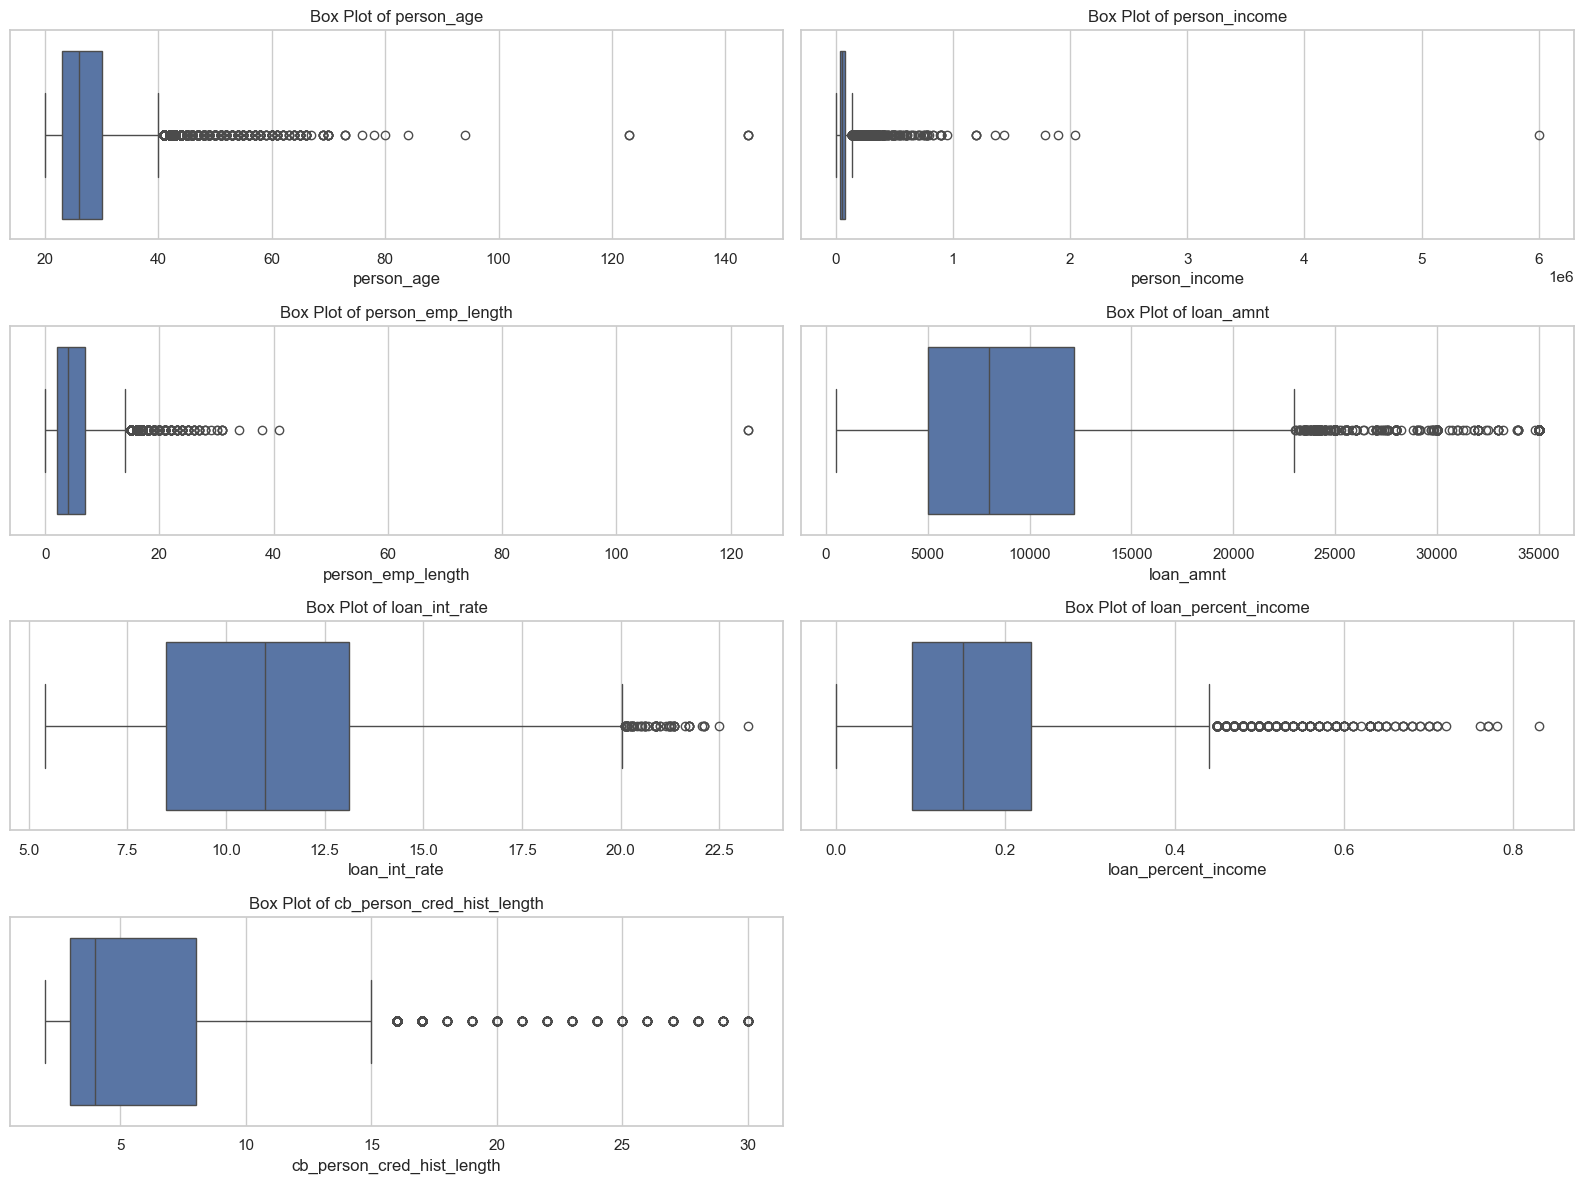

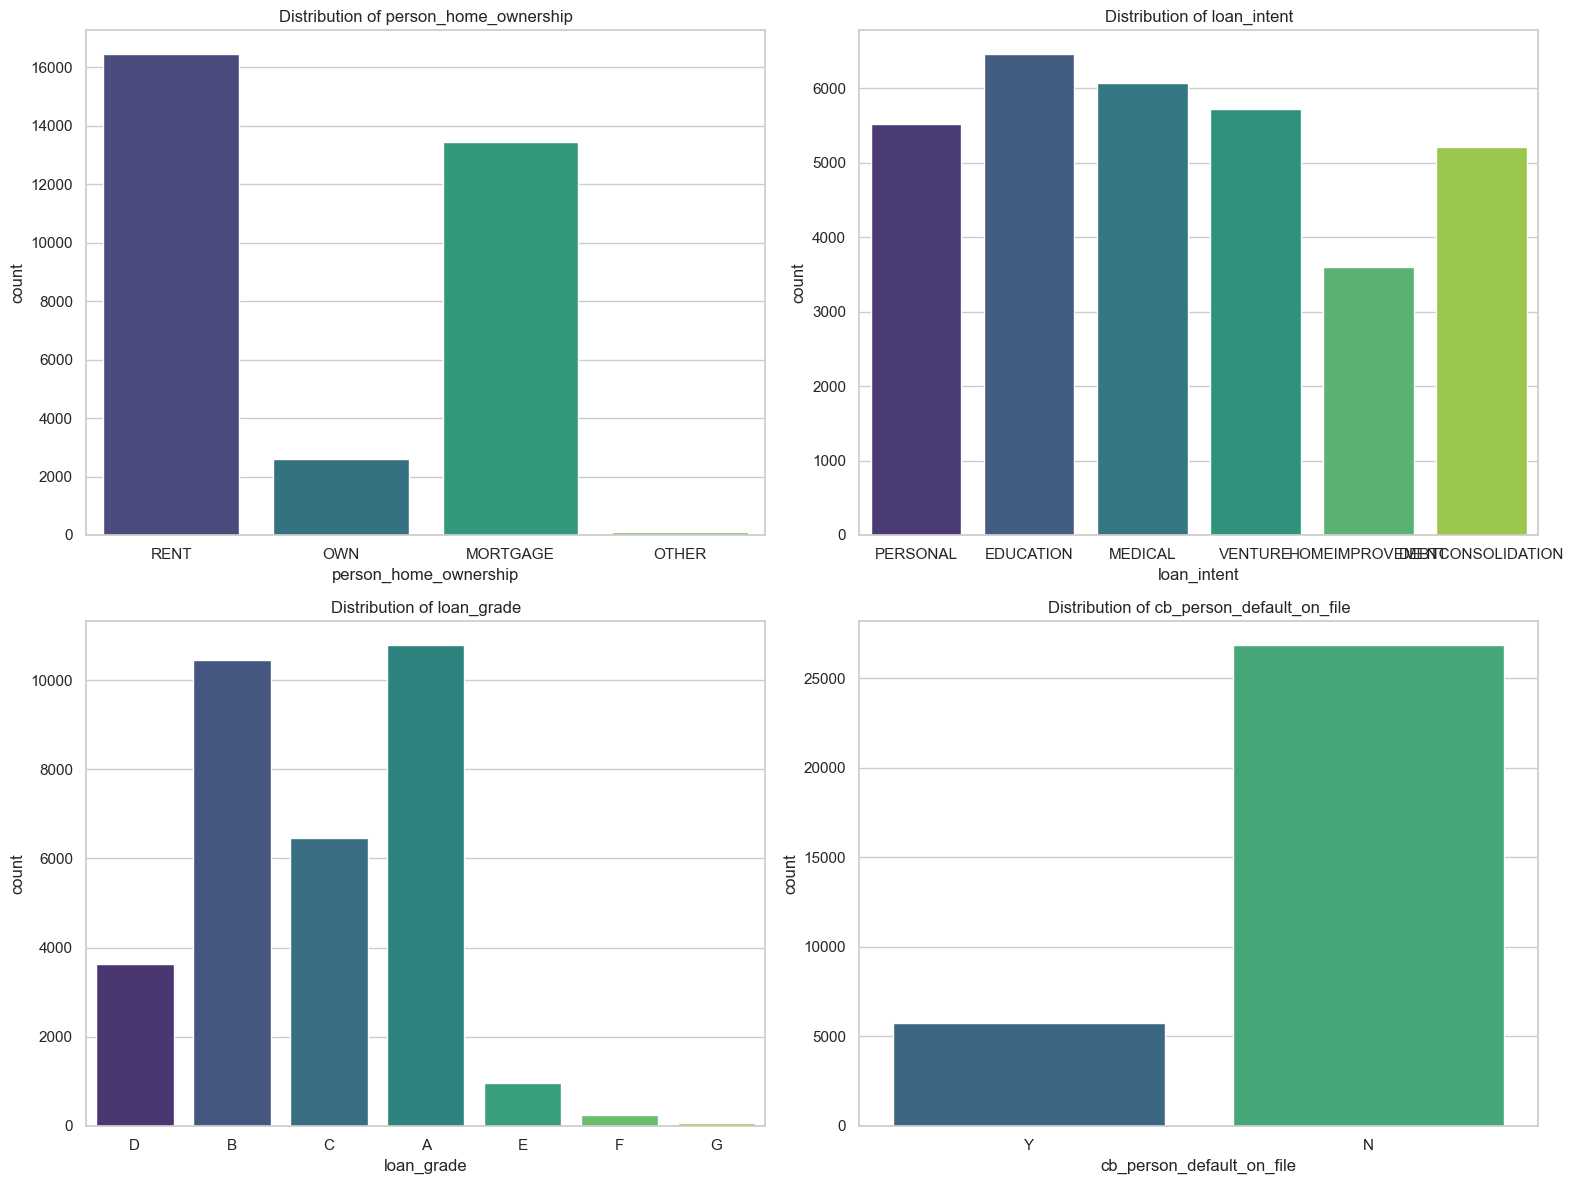

In [8]:
numeric_features = ['person_age', 'person_income', 'person_emp_length',
                    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                    'cb_person_cred_hist_length']
categorical_features = ['person_home_ownership', 'loan_intent',
                        'loan_grade', 'cb_person_default_on_file']

# Box plots for numeric
plt.figure(figsize=(16, 12))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# Count plots for categorical
plt.figure(figsize=(16, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=feature, data=df, palette="viridis")
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

6. TARGET DEFINITION 

In [9]:
# Standard convention: 1 = Default (Bad), 0 = Non-Default (Good)
# Checking unique values to be safe:
print("\nOriginal loan_status value counts:")
print(df['loan_status'].value_counts())

# If dataset has 1 = No Default, 0 = Default, we keep as-is.
# But we will interpret the model's probability of class 1 as "Default".
# Let's assume 0 = Non-Default, 1 = Default (standard).
# If data is opposite, adjust here:
# df['loan_status'] = 1 - df['loan_status']  # UNCOMMENT IF NEEDED

y = df['loan_status']  # 0 = good, 1 = default (most common in this dataset


Original loan_status value counts:
loan_status
0    25473
1     7108
Name: count, dtype: int64


7. PREPROCESSOR 

In [10]:
# IMPORTANT: We do NOT include 'Heuristic_Risk_Category' in X.
X = df.drop(columns=['loan_status', 'Heuristic_Risk_Category'])

# Define columns
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file']

# Numeric pipeline: Impute -> Scale (optionally Box-Cox)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute (most frequent) -> OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


8. TRAIN / TEST SPLIT

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.3f}")
print(f"Default rate in test:  {y_test.mean():.3f}")


Training set shape: (26064, 11)
Test set shape: (6517, 11)
Default rate in train: 0.218
Default rate in test:  0.218


9. MODEL 1: DECISION TREE

In [12]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print("\n" + "="*60)
print("DECISION TREE PERFORMANCE (No Heuristic Feature)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Recall (Default=1): {recall_score(y_test, y_pred_dt):.4f}")
print(f"Precision (Default=1): {precision_score(y_test, y_pred_dt):.4f}")
print(f"F1 (Default=1): {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:,1]):.4f}")


DECISION TREE PERFORMANCE (No Heuristic Feature)
Accuracy:  0.9033
Recall (Default=1): 0.5675
Precision (Default=1): 0.9818
F1 (Default=1): 0.7193
ROC AUC: 0.8736


10. MODEL 2: RANDOM FOREST + SMOTE 


Training Random Forest + SMOTE with GridSearch...
Fitting 5 folds for each of 54 candidates, totalling 270 fits



Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

RANDOM FOREST + SMOTE PERFORMANCE (Production Model)
Accuracy:  0.9093
Recall (Default=1): 0.7412
Precision (Default=1): 0.8254
F1 (Default=1): 0.7810
ROC AUC: 0.9202


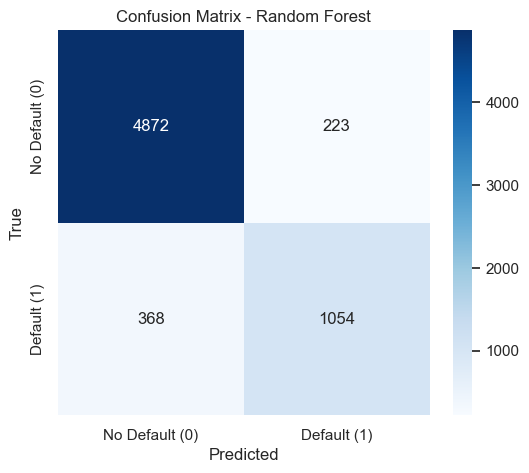


Classification Report:
              precision    recall  f1-score   support

  No Default       0.93      0.96      0.94      5095
     Default       0.83      0.74      0.78      1422

    accuracy                           0.91      6517
   macro avg       0.88      0.85      0.86      6517
weighted avg       0.91      0.91      0.91      6517



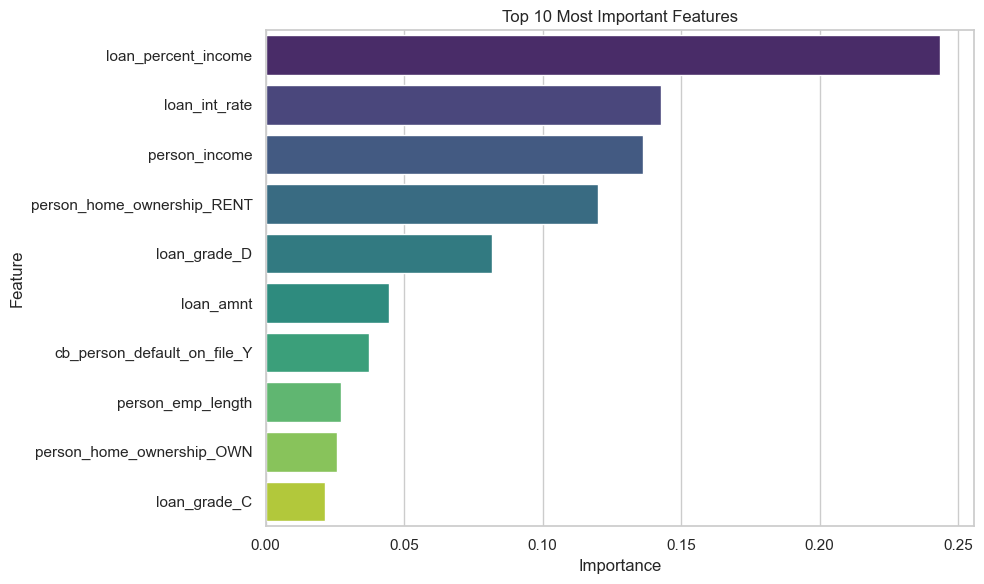

In [ ]:
# Builds a pipeline with SMOTE to handle class imbalance
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Hyperparameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=cv,
    scoring='recall',  # Optimises for catching defaults
    n_jobs=-1, verbose=1
)
print("\nTraining Random Forest + SMOTE with GridSearch...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"\nBest parameters: {grid_search.best_params_}")

# Evaluates
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]  # Prob of class 1 (Default)

print("\n" + "="*60)
print("RANDOM FOREST + SMOTE PERFORMANCE (Production Model)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall (Default=1): {recall_score(y_test, y_pred_rf):.4f}")
print(f"Precision (Default=1): {precision_score(y_test, y_pred_rf):.4f}")
print(f"F1 (Default=1): {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default (0)", "Default (1)"],
            yticklabels=["No Default (0)", "Default (1)"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))

# Feature Importance (Top 10)
# Get feature names after preprocessing
cat_feature_names = best_rf.named_steps['preprocessor'] \
                          .named_transformers_['cat'] \
                          .named_steps['onehot'] \
                          .get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

importances = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', orient='h')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

11. OPTIMAL THRESHOLD TUNING

In [14]:
# FindS the threshold that maximises F1 for the Default class (class 1)
thresholds = np.linspace(0.1, 0.9, 50)
best_threshold = 0.5
best_f1 = 0
for thresh in thresholds:
    preds = (y_proba_rf >= thresh).astype(int)
    f1 = f1_score(y_test, preds, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nOptimal threshold for Max F1 (Default class): {best_threshold:.2f}")

# Applies optimal threshold
y_pred_opt = (y_proba_rf >= best_threshold).astype(int)
print(f"F1 at optimal threshold: {f1_score(y_test, y_pred_opt, pos_label=1):.4f}")
print(f"Recall at optimal threshold: {recall_score(y_test, y_pred_opt):.4f}")


Optimal threshold for Max F1 (Default class): 0.62
F1 at optimal threshold: 0.8011
Recall at optimal threshold: 0.6997


12. SAVE MODEL

In [15]:
# SaveS the full pipeline + threshold
model_artifact = {
    'pipeline': best_rf,
    'threshold': best_threshold,
    'feature_names': all_feature_names,
    'preprocessor': preprocessor  # saved separately if needed
}
joblib.dump(model_artifact, 'credit_risk_production_model.pkl')
print("\n Model saved as 'credit_risk_production_model.pkl'")


 Model saved as 'credit_risk_production_model.pkl'


13. OPTIONAL: COMPARE WITH HEURISTIC

In [16]:
# to show why ML beats the rule-based approach
heuristic_pred = df.loc[X_test.index, 'Heuristic_Risk_Category'].map(
    {'Low Risk': 0, 'Moderate Risk': 0, 'High Risk': 1, 'Very High Risk': 1}
).fillna(0).astype(int)

print("\n" + "="*60)
print("HEURISTIC RULE PERFORMANCE (for comparison only)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, heuristic_pred):.4f}")
print(f"Recall (Default=1): {recall_score(y_test, heuristic_pred):.4f}")
print(f"Precision (Default=1): {precision_score(y_test, heuristic_pred):.4f}")

print("\n The ML model significantly outperforms the heuristic rule!")


HEURISTIC RULE PERFORMANCE (for comparison only)
Accuracy:  0.7816
Recall (Default=1): 0.0007
Precision (Default=1): 0.3333

 The ML model significantly outperforms the heuristic rule!


In [2]:
import joblib
import pandas as pd

# Load model
model_artifact = joblib.load('credit_risk_production_model.pkl')
pipeline = model_artifact['pipeline']
threshold = model_artifact['threshold']

def predict_loan_application(person_age, person_income, person_home_ownership,
                             person_emp_length, loan_intent, loan_grade,
                             loan_amnt, loan_int_rate, loan_percent_income,
                             cb_person_default_on_file, cb_person_cred_hist_length):
    """
    Returns probability of default and decision.
    """
    input_data = {
        'person_age': [person_age],
        'person_income': [person_income],
        'person_home_ownership': [person_home_ownership],
        'person_emp_length': [person_emp_length],
        'loan_intent': [loan_intent],
        'loan_grade': [loan_grade],
        'loan_amnt': [loan_amnt],
        'loan_int_rate': [loan_int_rate],
        'loan_percent_income': [loan_percent_income],
        'cb_person_default_on_file': [cb_person_default_on_file],
        'cb_person_cred_hist_length': [cb_person_cred_hist_length]
    }
    df = pd.DataFrame(input_data)
    proba = pipeline.predict_proba(df)[0, 1]
    prediction = int(proba >= threshold)
    decision = "APPROVED" if prediction == 0 else "DECLINED"
    return {'probability_of_default': proba, 'predicted_class': prediction, 'decision': decision}

# Test it
result = predict_loan_application(
    person_age=35,
    person_income=75000,
    person_home_ownership="MORTGAGE",
    person_emp_length=8,
    loan_intent="PERSONAL",
    loan_grade="B",
    loan_amnt=15000,
    loan_int_rate=12.5,
    loan_percent_income=0.2,
    cb_person_default_on_file="N",
    cb_person_cred_hist_length=10
)
print(result)

{'probability_of_default': np.float64(0.1687256229997644), 'predicted_class': 0, 'decision': 'APPROVED'}
